In [36]:
import os, numpy as np, agama, scipy.special, scipy.integrate, matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from IPython.display import Latex

agama.setUnits(length=1, velocity=1, mass=1)
#working in kiloparsec, km/s and M_sun


In [37]:
pot_sun_ideal = agama.Potential(dict(type='Plummer', mass =1, scaleRadius=2.2*1e-11))
pot_sun=agama.Potential(potential=pot_sun_ideal,center=[0,0,0])

In [38]:
pot_sun.potential([0,0,1]),agama.G

(-4.300917270677361e-06, 4.30091727067736e-06)

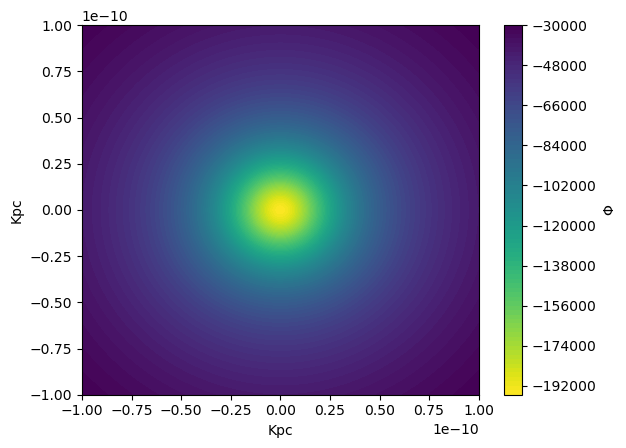

In [39]:
limit=1e-10
x = np.linspace(-1*limit, limit, 1000)
y = np.linspace(-1*limit, limit, 1000)
X, Y = np.meshgrid(x, y)

# Build (N, 3) array of points
points = np.c_[X.ravel(), Y.ravel(), np.zeros(X.size)]

# Evaluate potential
Z = pot_sun.potential(points).reshape(X.shape)

plt.contourf(X, Y, Z, levels=100, cmap='viridis_r')
plt.xlabel('Kpc')
plt.ylabel('Kpc')
plt.colorbar(label='Φ')
#plt.scatter(0.000025,0.000025,c='k')

In [40]:
mc_mass0=1e-6
mc_rvir=1e-3
mc_rs=1e-4
Nbody=1000

pot_mc_nfw  = agama.Potential(type='spheroid', gamma=1, beta=3, scaleradius=mc_rs, outercutoffradius=mc_rvir, mass=mc_mass0)
df_mc = agama.DistributionFunction(type='quasispherical', potential=pot_mc_nfw)
mc_mass0 = pot_mc_nfw.totalMass()
print('Minicluster mass in M_sun',mc_mass0)

mcp_xv, mcp_mass = agama.GalaxyModel(pot_mc_nfw, df_mc).sample(Nbody)

mcp_pot0=agama.Potential(type='multipole', particles=(mcp_xv[:,0:3] , mcp_mass), symmetry='n', lmax=50)


Minicluster mass in M_sun 9.999999999999997e-07


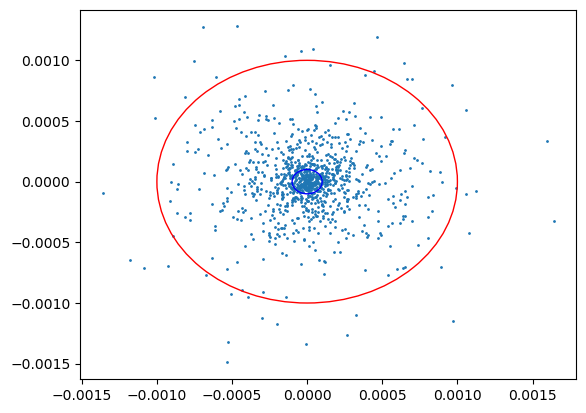

In [41]:
plt.scatter(mcp_xv[:,0],mcp_xv[:,1],s=1)

circle_rvir = plt.Circle((0, 0), mc_rvir, color='r', fill=False, label=f'r_vir={mc_rvir}')
circle_rs = plt.Circle((0, 0), mc_rs, color='b', fill=False, label=f'r_s={mc_rs}')
plt.gca().add_patch(circle_rvir)
plt.gca().add_patch(circle_rs)


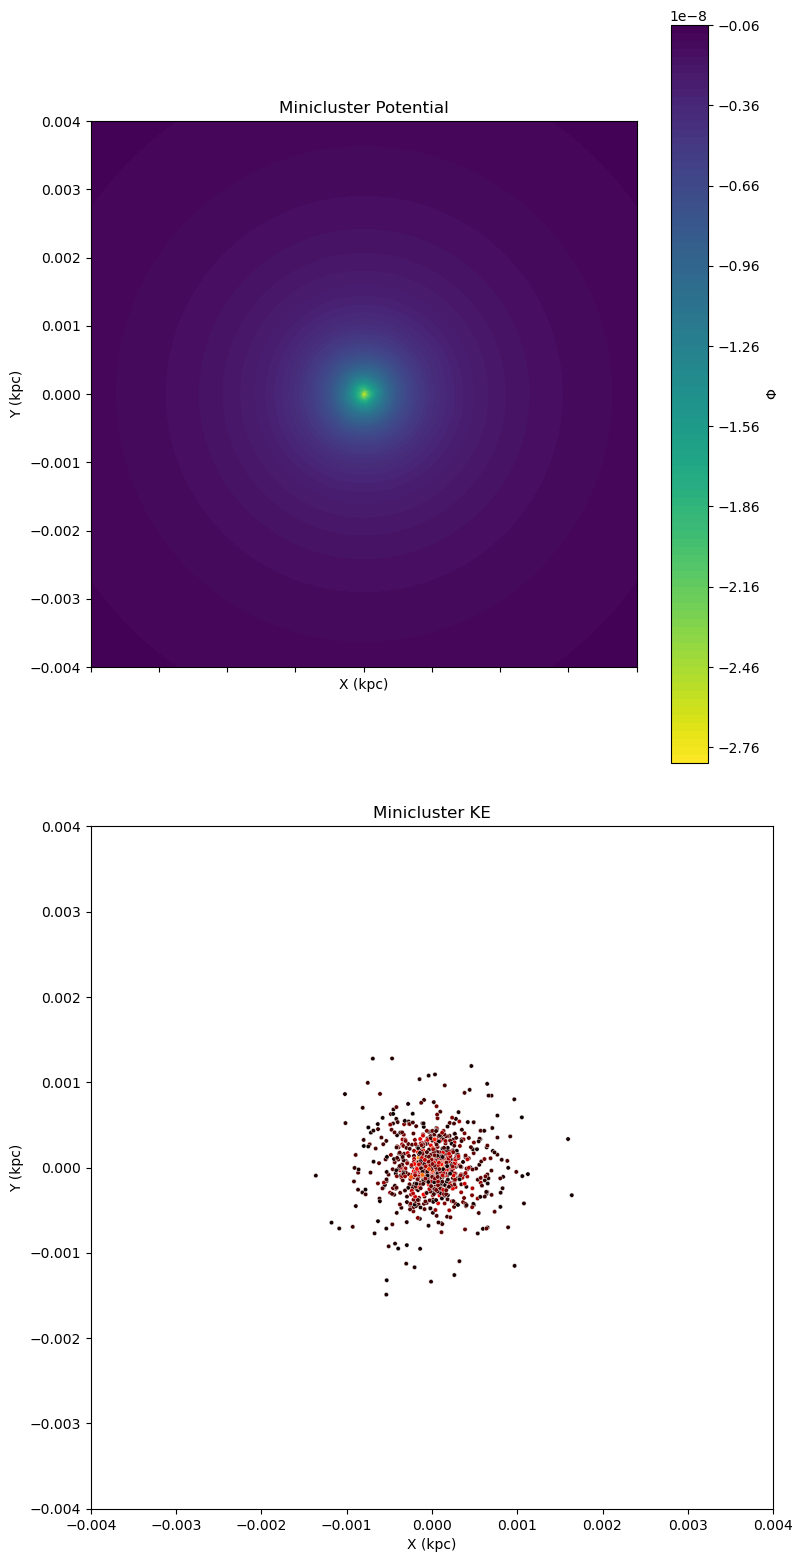

In [51]:
# --- Offset minicluster potential ---
mc_center = [0, 0, 0]
mcp_pot = agama.Potential(potential=mcp_pot0, center=mc_center)

# --- Create 2D evaluation grid in the X-Y plane ---
ngrid = 500
x = np.linspace(-0.004, 0.004, ngrid)
y = np.linspace(-0.004, 0.004, ngrid)
X, Y = np.meshgrid(x, y)
points = np.column_stack([X.ravel(), Y.ravel(), np.zeros(X.size)])

# --- Evaluate gravitational potential on the grid ---
Phi = mcp_pot.potential(points).reshape(X.shape)

# --- Particle kinetic energy ---
KE = 0.5 * np.sum(mcp_xv[:, 3:]**2, axis=1)

# --- Plot ---
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(8, 16),sharex=True,sharey=True)

# Potential contour map
cf = ax1.contourf(X, Y, Phi, levels=100, cmap='viridis_r')
fig.colorbar(cf, ax=ax1, label=r'$\Phi$')

# Overlay particles colored by kinetic energy
sc = ax2.scatter(mcp_xv[:, 0] + mc_center[0],mcp_xv[:, 1] + mc_center[1],c=KE, s=10, cmap='hot', edgecolors='white', linewidths=0.3,zorder=5)
fig.colorbar(sc, ax=ax, label=r'KE')


ax1.set_xlabel('X (kpc)')
ax1.set_ylabel('Y (kpc)')
ax1.set_title('Minicluster Potential')
ax1.set_aspect('equal')

ax2.set_xlabel('X (kpc)')
ax2.set_ylabel('Y (kpc)')
ax2.set_title('Minicluster KE')
ax2.set_aspect('equal')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [50]:
# Offset minicluster from Sun
mc_center = [0.005, 0, 0]  # Place minicluster 5 pc from Sun
mcp_pot = agama.Potential(potential=mcp_pot0, center=mc_center)
pot_total = agama.Potential(pot_sun, mcp_pot)

(np.float64(-0.008), np.float64(0.008), np.float64(-0.008), np.float64(0.008))

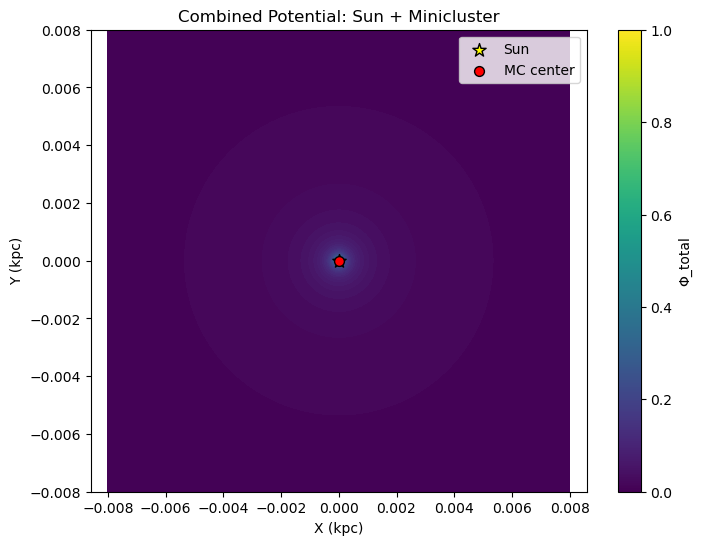

In [52]:
# Improved combined potential visualization
limit = 0.008  # Focus on region with both objects
x = np.linspace(-limit, limit, 200)  # Symmetric range
y = np.linspace(-limit, limit, 200)  # Symmetric range
X, Y = np.meshgrid(x, y)

# Build (N, 3) array of points
points = np.c_[X.ravel(), Y.ravel(), np.zeros(X.size)]

# Evaluate potential
Z = pot_total.potential(points).reshape(X.shape)

plt.figure(figsize=(8,6))
plt.contourf(X, Y, Z, levels=100, cmap='viridis_r')
plt.scatter([0], [0], c='yellow', s=100, marker='*', label='Sun', edgecolors='k')
plt.scatter([mc_center[0]], [mc_center[1]], c='red', s=50, marker='o', label='MC center', edgecolors='k')
plt.xlabel('X (kpc)')
plt.ylabel('Y (kpc)')
plt.colorbar(label='Φ_total')
plt.legend()
plt.title('Combined Potential: Sun + Minicluster')
plt.axis('equal')

In [54]:

# ────────────────────────────────────────────────────────────
# FLYBY SETUP
# ────────────────────────────────────────────────────────────
# v_inf:    MC speed relative to Sun (typical DM velocity ~220 km/s)
# d_impact: closest approach distance (impact parameter for ~straight-line flyby)
# d_start:  starting distance from Sun

v_inf    = 220.0   # km/s
d_impact = 0.005   # kpc  (5 pc)
d_start  = 0.10    # kpc  (100 pc)

# MC centre starts at (-d_start, d_impact, 0), moving in +x direction
mc_ic = np.array([-d_start, d_impact, 0.0, v_inf, 0.0, 0.0])

# Shift particles into Sun frame:
#   mcp_xv contains particles centred at origin (from the earlier sampling cell)
mcp_xv_sim = mcp_xv.copy()
mcp_xv_sim[:, 0:3] += mc_ic[0:3]   # translate positions
mcp_xv_sim[:, 3:6] += mc_ic[3:6]   # add bulk velocity

# Initial MC self-gravity potential (particles relative to MC centre)
mc_sg = agama.Potential(type='multipole',
                        particles=(mcp_xv[:, 0:3], mcp_mass),
                        symmetry='a', lmax=4)

t_flyby_myr = (2 * d_start / v_inf) * 977.8   # 1 kpc/(km/s) = 977.8 Myr
print(f"v_inf = {v_inf} km/s  |  d_impact = {d_impact*1e3:.0f} pc  |  d_start = {d_start*1e3:.0f} pc")
print(f"Total flyby duration ≈ {t_flyby_myr:.3f} Myr")
print(f"Expected perihelion ≈ {d_impact*1e3:.1f} pc  (impact parameter, Sun barely deflects at this speed)")


v_inf = 220.0 km/s  |  d_impact = 5 pc  |  d_start = 100 pc
Total flyby duration ≈ 0.889 Myr
Expected perihelion ≈ 5.0 pc  (impact parameter, Sun barely deflects at this speed)


In [13]:

# ────────────────────────────────────────────────────────────
# SIMULATION: adaptive timestep (dt ∝ d_sun, flyby scaling)
# ────────────────────────────────────────────────────────────
# For a hyperbolic flyby at roughly constant speed v_inf,
# the relevant timescale at distance d is t ~ d/v_inf  →  dt ∝ d^1.0
# (d^1.5 Keplerian scaling is only correct for bound orbits where v ∝ d^-0.5)
sim_time  = 2 * d_start / v_inf    # total integration time [kpc/(km/s)]

tupd_max = sim_time / 50           # coarse step when MC is far (~d_start)
tupd_min = sim_time / 2000         # finest step allowed

def adaptive_dt(d_sun):
    """Linear scaling: dt ∝ d/v_inf (correct for constant-speed flyby)."""
    return float(np.clip(tupd_max * (d_sun / d_start), tupd_min, tupd_max))

# Accumulators
all_t      = []
d_sun_all  = []
bound_frac = []

snap_interval = t_flyby_myr / 9
snap_t, snap_xv_list, snap_mc_list, snap_sg_list, snap_bf = [], [], [], [], []
last_snap_t = -np.inf

mc_ic_cur  = mc_ic.copy()
mcp_xv_cur = mcp_xv_sim.copy()
mc_sg_cur  = mc_sg
t_cur      = 0.0
n_steps    = 0

# d at which tupd_min clamps in:  d_clamp = d_start * tupd_min/tupd_max
d_clamp_pc = d_start * 1e3 * (tupd_min / tupd_max)
print(f"Adaptive timestep:  dt_max = {tupd_max*977.8*1e3:.1f} kyr  |  dt_min = {tupd_min*977.8*1e3:.2f} kyr")
print(f"Clamping kicks in below d = {d_clamp_pc:.1f} pc  (d_impact = {d_impact*1e3:.0f} pc)")
print(f"Total sim time: {t_flyby_myr:.3f} Myr\n")

while t_cur < sim_time:
    d_sun = np.linalg.norm(mc_ic_cur[:3])
    tupd  = min(adaptive_dt(d_sun), sim_time - t_cur)

    # 1. Integrate MC centre in solar potential only
    t_mc, traj_mc = agama.orbit(ic=mc_ic_cur, potential=pot_sun,
                                 time=tupd, timestart=t_cur,
                                 trajsize=50, accuracy=1e-10)
    mc_ic_cur = traj_mc[-1]

    # 2. Total potential: Sun + MC self-gravity moving along its orbit
    pot_total = agama.Potential(
        pot_sun,
        agama.Potential(potential=mc_sg_cur,
                        center=np.column_stack((t_mc, traj_mc[:, 0:3])))
    )

    # 3. Integrate all particles for one timestep
    mcp_xv_cur = np.vstack(
        agama.orbit(ic=mcp_xv_cur, potential=pot_total,
                    time=tupd, timestart=t_cur, trajsize=1, accuracy=1e-10)[:, 1]
    )

    # 4. Rebuild MC self-gravity from updated particle positions
    dr = mcp_xv_cur[:, 0:3] - mc_ic_cur[0:3]
    mc_sg_cur = agama.Potential(type='multipole',
                                 particles=(dr, mcp_mass),
                                 symmetry='a', lmax=4)

    # 5. Bound/unbound: total energy in MC rest frame
    dv    = mcp_xv_cur[:, 3:6] - mc_ic_cur[3:6]
    E_int = 0.5 * np.sum(dv**2, axis=1) + mc_sg_cur.potential(dr)
    bound = E_int < 0

    t_cur += tupd
    t_now  = t_cur * 977.8
    bf     = np.sum(mcp_mass[bound]) / np.sum(mcp_mass)

    all_t.append(t_now)
    d_sun_all.append(np.linalg.norm(mc_ic_cur[:3]) * 1e3)
    bound_frac.append(bf)
    n_steps += 1

    if t_now - last_snap_t >= snap_interval or t_cur >= sim_time:
        snap_t.append(t_now)
        snap_xv_list.append(mcp_xv_cur.copy())
        snap_mc_list.append(mc_ic_cur.copy())
        snap_sg_list.append(mc_sg_cur)
        snap_bf.append(bf)
        last_snap_t = t_now
        print(f"  t={t_now:.3f} Myr  d_Sun={d_sun_all[-1]:.2f} pc"
              f"  dt={tupd*977.8*1e3:.2f} kyr  bound={np.sum(bound):4d}/{Nbody}")

all_t      = np.array(all_t)
d_sun_all  = np.array(d_sun_all)
bound_frac = np.array(bound_frac)
snap_t     = np.array(snap_t)
i_peri     = np.argmin(d_sun_all)

print(f"\nSimulation complete!  Total steps: {n_steps}")


Adaptive timestep:  dt_max = 17.8 kyr  |  dt_min = 0.44 kyr
Clamping kicks in below d = 2.5 pc  (d_impact = 5 pc)
Total sim time: 0.889 Myr

  t=0.018 Myr  d_Sun=96.13 pc  dt=17.78 kyr  bound=1000/1000
  t=0.124 Myr  d_Sun=72.28 pc  dt=13.38 kyr  bound=1000/1000


1000 orbits complete (125000 orbits/s)
1000 orbits complete (125000 orbits/s)
1000 orbits complete (125000 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (125000 orbits/s)
1000 orbits complete (125000 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (125000 orbits/s)
1000 orbits complete (125000 orbits/s)
1000 orbits complete (125000 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (125000 orbits/s)
1000 orbits complete (125000 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142

  t=0.223 Myr  d_Sun=50.12 pc  dt=9.28 kyr  bound=1000/1000


1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)


  t=0.325 Myr  d_Sun=27.34 pc  dt=5.06 kyr  bound=1000/1000


...

1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (125000 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142

  t=0.524 Myr  d_Sun=18.54 pc  dt=3.17 kyr  bound=1000/1000


1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (125

  t=0.628 Myr  d_Sun=41.63 pc  dt=7.12 kyr  bound=1000/1000
  t=0.728 Myr  d_Sun=63.95 pc  dt=10.93 kyr  bound=1000/1000
  t=0.833 Myr  d_Sun=87.46 pc  dt=14.95 kyr  bound=1000/1000
  t=0.889 Myr  d_Sun=100.12 pc  dt=7.82 kyr  bound=1000/1000

Simulation complete!  Total steps: 185


1000 orbits complete (125000 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (125000 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)
1000 orbits complete (142857 orbits/s)


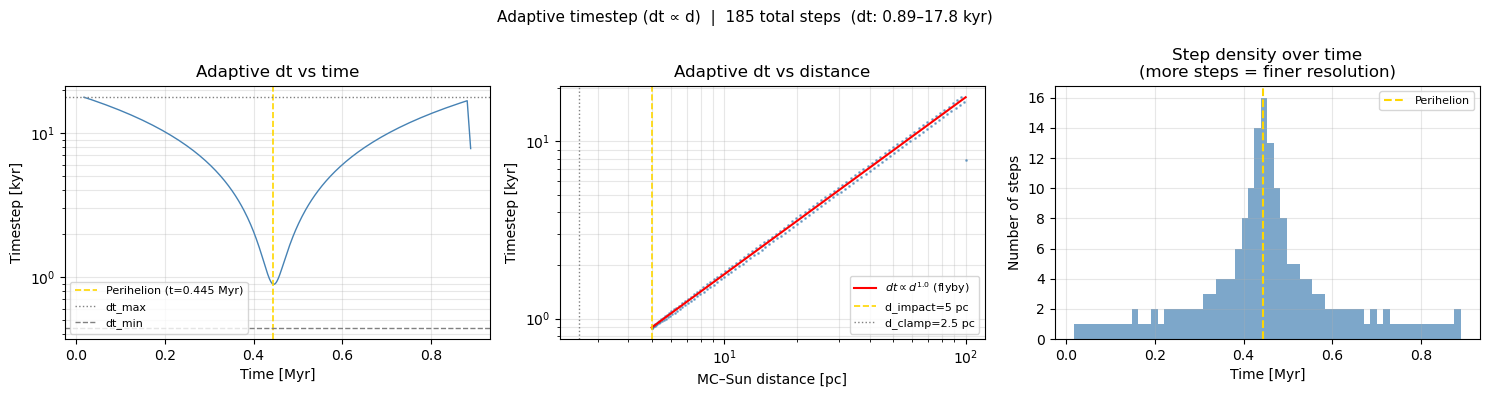

In [14]:

# ────────────────────────────────────────────────────────────
# DIAGNOSTIC: visualise the adaptive timestep
# ────────────────────────────────────────────────────────────
dt_kyr = np.diff(np.concatenate([[0], all_t])) * 1e3   # Myr → kyr

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Panel 1: timestep vs time ─────────────────────────────
ax = axes[0]
ax.semilogy(all_t, dt_kyr, color='steelblue', lw=1)
ax.axvline(all_t[i_peri], color='gold', ls='--', lw=1.2,
           label=f'Perihelion (t={all_t[i_peri]:.3f} Myr)')
ax.axhline(tupd_max*977.8*1e3, color='gray', ls=':', lw=1, label='dt_max')
ax.axhline(tupd_min*977.8*1e3, color='gray', ls='--', lw=1, label='dt_min')
ax.set_xlabel('Time [Myr]')
ax.set_ylabel('Timestep [kyr]')
ax.set_title('Adaptive dt vs time')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which='both')

# ── Panel 2: timestep vs MC–Sun distance ─────────────────
ax = axes[1]
ax.loglog(d_sun_all, dt_kyr, '.', ms=2, color='steelblue', alpha=0.6)
d_theory = np.logspace(np.log10(d_sun_all.min()), np.log10(d_sun_all.max()), 200)
dt_theory = np.clip(tupd_max * (d_theory / (d_start*1e3))**1.0, tupd_min, tupd_max) * 977.8*1e3
ax.loglog(d_theory, dt_theory, 'r-', lw=1.5, label=r'$dt \propto d^{1.0}$ (flyby)')
ax.axvline(d_impact*1e3, color='gold', ls='--', lw=1.2,
           label=f'd_impact={d_impact*1e3:.0f} pc')
ax.axvline(d_clamp_pc, color='gray', ls=':', lw=1,
           label=f'd_clamp={d_clamp_pc:.1f} pc')
ax.set_xlabel('MC–Sun distance [pc]')
ax.set_ylabel('Timestep [kyr]')
ax.set_title('Adaptive dt vs distance')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which='both')

# ── Panel 3: step density (histogram of simulation times) ─
ax = axes[2]
ax.hist(all_t, bins=60, color='steelblue', alpha=0.7)
ax.axvline(all_t[i_peri], color='gold', ls='--', lw=1.5, label='Perihelion')
ax.set_xlabel('Time [Myr]')
ax.set_ylabel('Number of steps')
ax.set_title('Step density over time\n(more steps = finer resolution)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.suptitle(
    f'Adaptive timestep (dt ∝ d)  |  {n_steps} total steps  '
    f'(dt: {dt_kyr.min():.2f}–{dt_kyr.max():.1f} kyr)',
    fontsize=11)
plt.tight_layout()
plt.show()


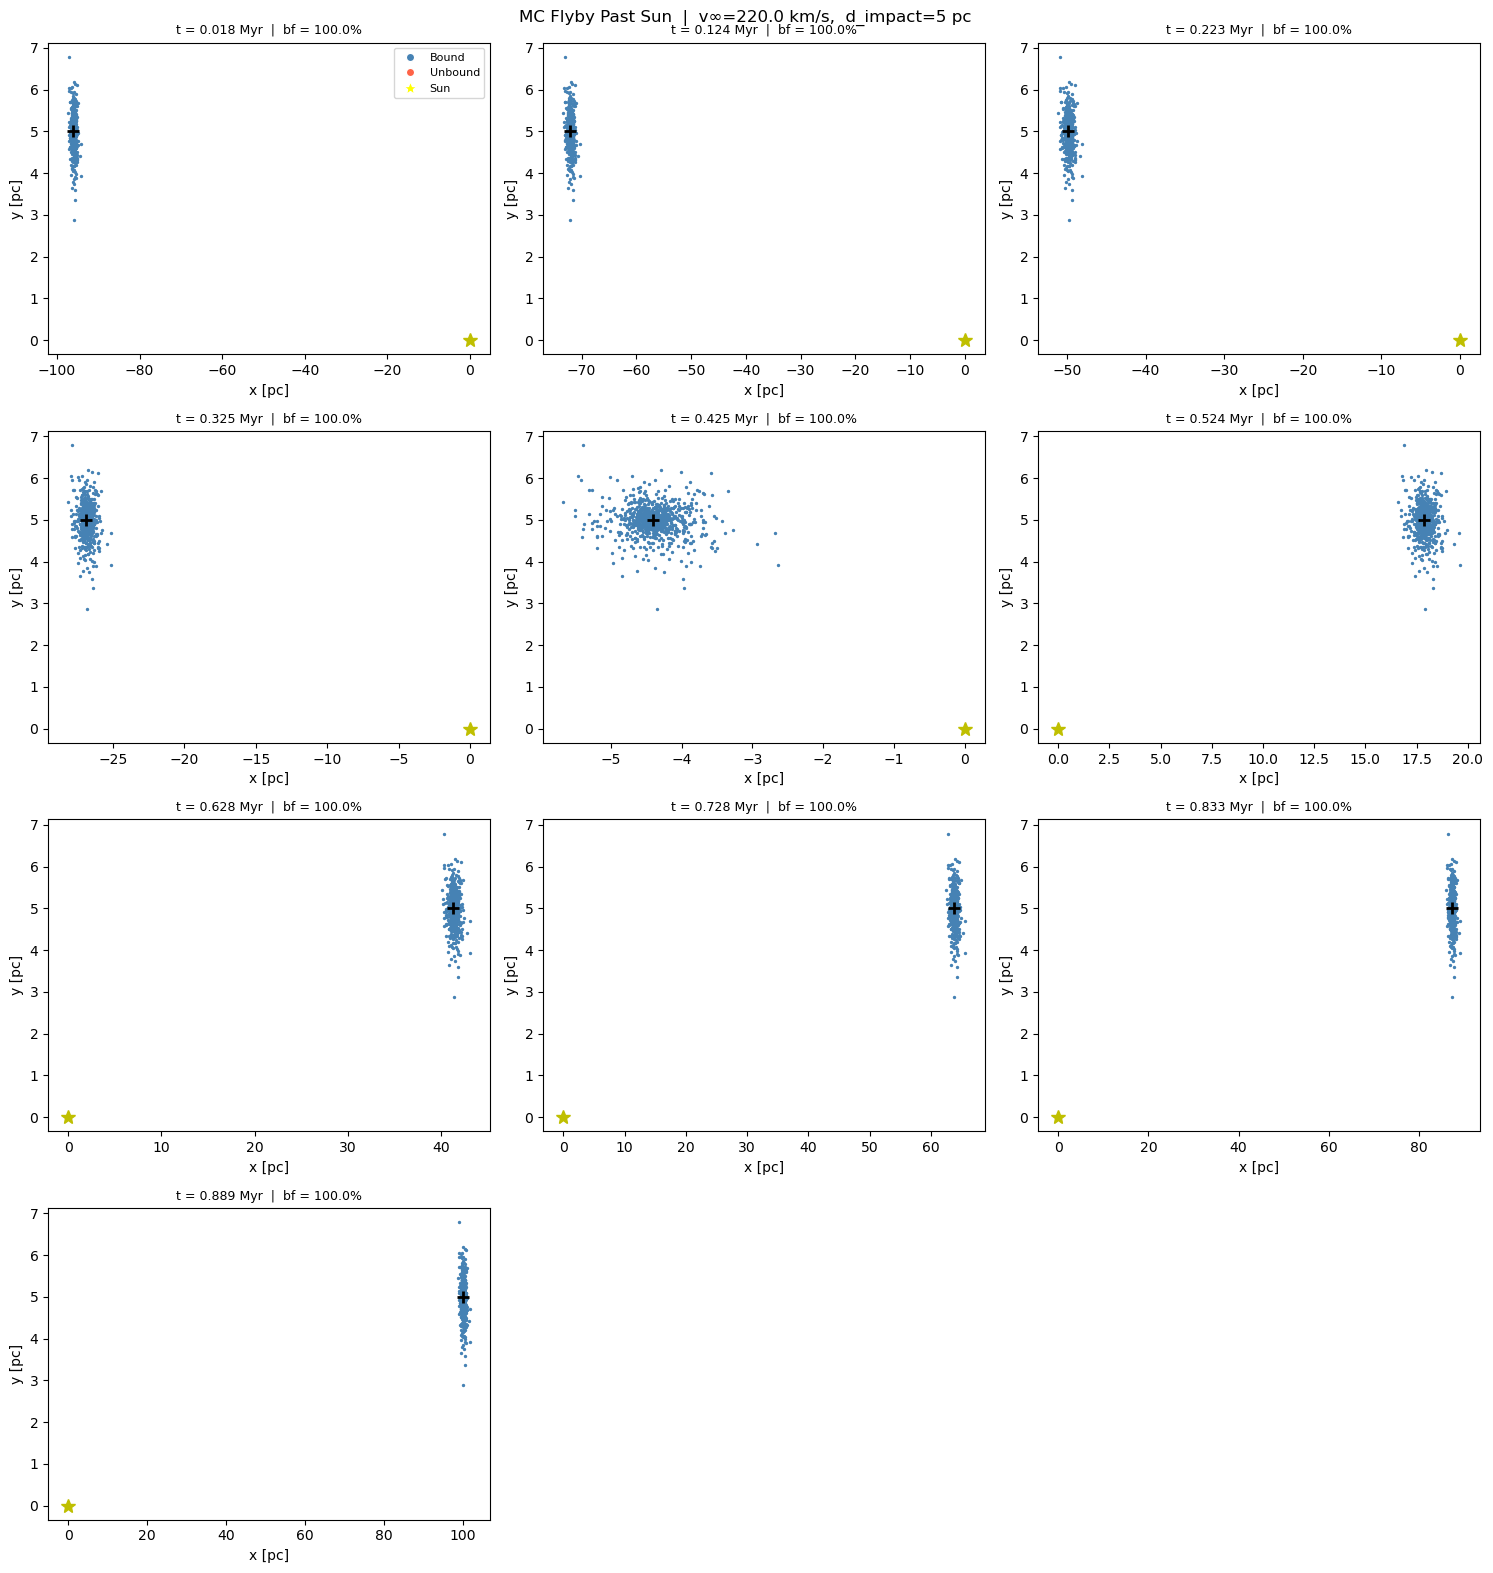

In [15]:

# ────────────────────────────────────────────────────────────
# PLOT: particle distribution at selected snapshots
# ────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D

n_snap = len(snap_t)
ncols  = 3
nrows  = int(np.ceil(n_snap / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes_flat = np.array(axes).ravel()

for k in range(len(axes_flat)):
    ax = axes_flat[k]
    if k >= n_snap:
        ax.set_visible(False)
        continue

    xv  = snap_xv_list[k]
    mc  = snap_mc_list[k]
    sg  = snap_sg_list[k]

    dr     = xv[:, 0:3] - mc[0:3]
    dv     = xv[:, 3:6] - mc[3:6]
    E_int  = 0.5 * np.sum(dv**2, axis=1) + sg.potential(dr)
    bound_k = E_int < 0

    x_pc, y_pc = xv[:, 0]*1e3, xv[:, 1]*1e3

    ax.scatter(x_pc[~bound_k], y_pc[~bound_k], s=1, c='tomato',    alpha=0.4)
    ax.scatter(x_pc[bound_k],  y_pc[bound_k],  s=2, c='steelblue')
    ax.plot(0, 0, 'y*', ms=10, zorder=5)
    ax.plot(mc[0]*1e3, mc[1]*1e3, 'w+', ms=8, mew=2, zorder=5,
            markeredgecolor='black')
    ax.set_xlabel('x [pc]')
    ax.set_ylabel('y [pc]')
    ax.set_title(f't = {snap_t[k]:.3f} Myr  |  bf = {snap_bf[k]:.1%}', fontsize=9)

legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', ms=6, label='Bound'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',    ms=6, label='Unbound'),
    Line2D([0],[0], marker='*', color='w', markerfacecolor='yellow',    ms=10, label='Sun'),
]
axes_flat[0].legend(handles=legend_elements, fontsize=8, loc='upper right')

fig.suptitle(f'MC Flyby Past Sun  |  v∞={v_inf} km/s,  d_impact={d_impact*1e3:.0f} pc',
             fontsize=12)
plt.tight_layout()
plt.show()


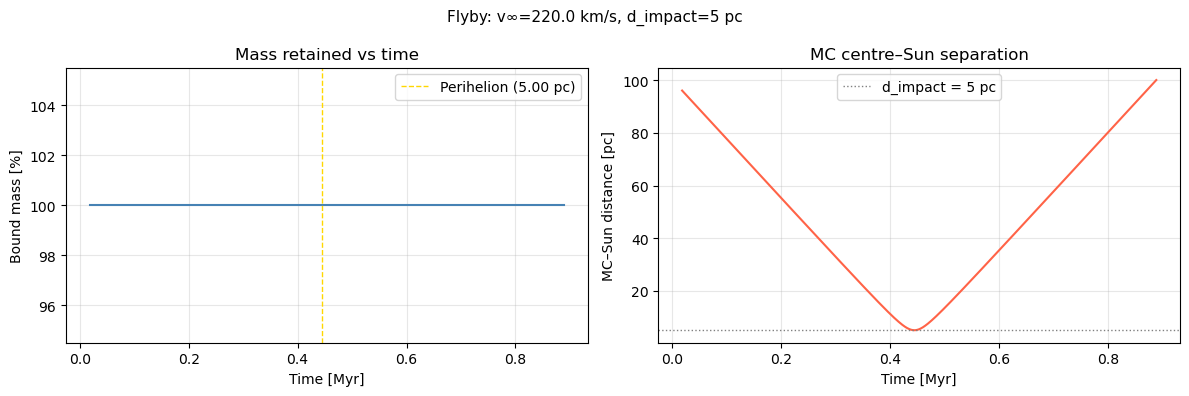

Perihelion: 5.00 pc at t = 0.445 Myr
Bound mass: initial=100.0%  at perihelion=100.0%  final=100.0%
Total mass loss: 0.0%


In [16]:

# ────────────────────────────────────────────────────────────
# PLOT: bound fraction and MC–Sun distance over time
# ────────────────────────────────────────────────────────────
i_peri    = np.argmin(d_sun_all)
t_peri    = all_t[i_peri]
d_peri_pc = d_sun_all[i_peri]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(all_t, bound_frac * 100, 'steelblue', lw=1.5)
ax1.axvline(t_peri, color='gold', ls='--', lw=1, label=f'Perihelion ({d_peri_pc:.2f} pc)')
ax1.set_xlabel('Time [Myr]')
ax1.set_ylabel('Bound mass [%]')
ax1.set_title('Mass retained vs time')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(all_t, d_sun_all, 'tomato', lw=1.5)
ax2.axhline(d_impact * 1e3, color='gray', ls=':', lw=1,
            label=f'd_impact = {d_impact*1e3:.0f} pc')
ax2.set_xlabel('Time [Myr]')
ax2.set_ylabel('MC–Sun distance [pc]')
ax2.set_title('MC centre–Sun separation')
ax2.legend()
ax2.grid(alpha=0.3)

fig.suptitle(f'Flyby: v∞={v_inf} km/s, d_impact={d_impact*1e3:.0f} pc', fontsize=11)
plt.tight_layout()
plt.show()

print(f"Perihelion: {d_peri_pc:.2f} pc at t = {t_peri:.3f} Myr")
print(f"Bound mass: initial={bound_frac[0]:.1%}  at perihelion={bound_frac[i_peri]:.1%}  final={bound_frac[-1]:.1%}")
print(f"Total mass loss: {(1 - bound_frac[-1]) * 100:.1f}%")


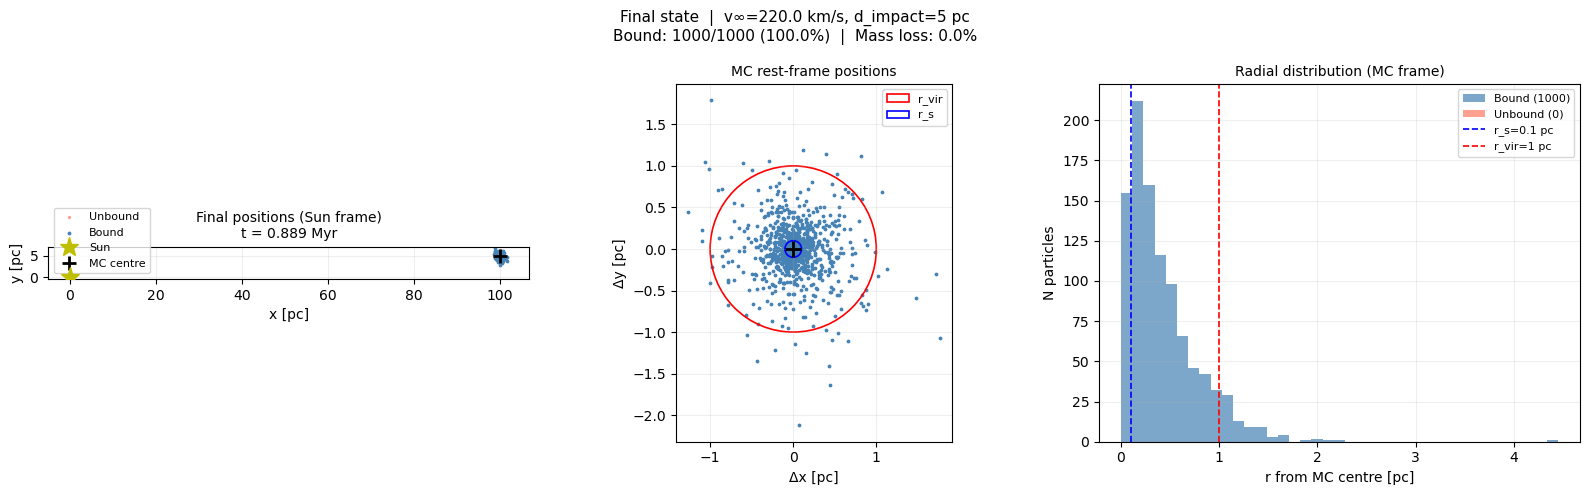

In [17]:

# ────────────────────────────────────────────────────────────
# PLOT: final particle distribution
# ────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D

xv_fin  = snap_xv_list[-1]
mc_fin  = snap_mc_list[-1]
sg_fin  = snap_sg_list[-1]

dr_fin  = xv_fin[:, 0:3] - mc_fin[0:3]
dv_fin  = xv_fin[:, 3:6] - mc_fin[3:6]
E_int   = 0.5 * np.sum(dv_fin**2, axis=1) + sg_fin.potential(dr_fin)
bound   = E_int < 0
unbound = ~bound

r_fin   = np.linalg.norm(dr_fin, axis=1) * 1e3  # pc, MC-centred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel 1: sky-plane positions (Sun frame) ──────────────────
ax = axes[0]
ax.scatter(xv_fin[unbound, 0]*1e3, xv_fin[unbound, 1]*1e3,
           s=2, c='tomato', alpha=0.5, label='Unbound')
ax.scatter(xv_fin[bound,   0]*1e3, xv_fin[bound,   1]*1e3,
           s=3, c='steelblue', label='Bound')
ax.plot(0, 0, 'y*', ms=14, zorder=6, label='Sun')
ax.plot(mc_fin[0]*1e3, mc_fin[1]*1e3, 'w+', ms=10, mew=2,
        markeredgecolor='k', zorder=6, label='MC centre')
ax.set_xlabel('x [pc]')
ax.set_ylabel('y [pc]')
ax.set_title(f'Final positions (Sun frame)\nt = {snap_t[-1]:.3f} Myr', fontsize=10)
ax.legend(fontsize=8)
ax.set_aspect('equal')
ax.grid(alpha=0.2)

# ── Panel 2: MC rest-frame positions ─────────────────────────
ax = axes[1]
ax.scatter(dr_fin[unbound, 0]*1e3, dr_fin[unbound, 1]*1e3,
           s=2, c='tomato', alpha=0.5)
ax.scatter(dr_fin[bound,   0]*1e3, dr_fin[bound,   1]*1e3,
           s=3, c='steelblue')
ax.plot(0, 0, 'k+', ms=12, mew=2, zorder=5)
for rv, lbl, col in [(mc_rvir*1e3,'r_vir','r'), (mc_rs*1e3,'r_s','b')]:
    circ = plt.Circle((0,0), rv, color=col, fill=False, lw=1.2, label=lbl)
    ax.add_patch(circ)
ax.set_xlabel('Δx [pc]')
ax.set_ylabel('Δy [pc]')
ax.set_title('MC rest-frame positions', fontsize=10)
ax.legend(fontsize=8)
ax.set_aspect('equal')
ax.grid(alpha=0.2)

# ── Panel 3: radial distribution (MC-centred) ─────────────────
ax = axes[2]
r_max = max(r_fin.max(), mc_rvir*1e3)
bins  = np.linspace(0, r_max, 40)
ax.hist(r_fin[bound],   bins=bins, color='steelblue', alpha=0.7,
        label=f'Bound ({bound.sum()})')
ax.hist(r_fin[unbound], bins=bins, color='tomato',    alpha=0.6,
        label=f'Unbound ({unbound.sum()})')
ax.axvline(mc_rs*1e3,  color='b', ls='--', lw=1.2, label=f'r_s={mc_rs*1e3:.1f} pc')
ax.axvline(mc_rvir*1e3,color='r', ls='--', lw=1.2, label=f'r_vir={mc_rvir*1e3:.0f} pc')
ax.set_xlabel('r from MC centre [pc]')
ax.set_ylabel('N particles')
ax.set_title('Radial distribution (MC frame)', fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

fig.suptitle(
    f'Final state  |  v∞={v_inf} km/s, d_impact={d_impact*1e3:.0f} pc\n'
    f'Bound: {bound.sum()}/{Nbody} ({bound.sum()/Nbody:.1%})  |  '
    f'Mass loss: {(1-bound_frac[-1])*100:.1f}%',
    fontsize=11)
plt.tight_layout()
plt.show()


In [18]:

# ────────────────────────────────────────────────────────────
# ENERGY: Initial (E_0) and Final (E_new) total minicluster energy
# ────────────────────────────────────────────────────────────
# Total energy = KE + 0.5 * PE  (the 0.5 avoids double-counting the
# pairwise potential in an N-body self-gravitating system)

# --- Initial energy (MC rest frame, before flyby) ---
dr_0 = mcp_xv[:, 0:3]   # particles sampled centred at origin → already in MC frame
dv_0 = mcp_xv[:, 3:6]   # velocities in MC rest frame (bulk velocity not yet added)

KE_0 = 0.5 * np.sum(mcp_mass * np.sum(dv_0**2, axis=1))
PE_0 = 0.5 * np.sum(mcp_mass * mc_sg.potential(dr_0))
E_0  = KE_0 + PE_0

# --- Final energy (MC rest frame, after flyby) ---
dr_new = mcp_xv_cur[:, 0:3] - mc_ic_cur[0:3]
dv_new = mcp_xv_cur[:, 3:6] - mc_ic_cur[3:6]

KE_new = 0.5 * np.sum(mcp_mass * np.sum(dv_new**2, axis=1))
PE_new = 0.5 * np.sum(mcp_mass * mc_sg_cur.potential(dr_new))
E_new  = KE_new + PE_new

print(f"Initial total energy  E_0   = {E_0:.6e}")
print(f"Final   total energy  E_new = {E_new:.6e}")
print(f"ΔE = E_new - E_0           = {E_new - E_0:.6e}")
print(f"ΔE / |E_0|                 = {(E_new - E_0) / abs(E_0):.4%}")


Initial total energy  E_0   = -2.822322e-15
Final   total energy  E_new = -2.811841e-15
ΔE = E_new - E_0           = 1.048130e-17
ΔE / |E_0|                 = 0.3714%
